# Section Summary: Exploratory Data Analysis

## Goal

The goal of this notebook is to explore pricing patterns, host behavior, review trends, and neighborhood-level insights in the New York City Airbnb market.

## Objectives

- Analyze price distributions.
- Compare room types and property types.
- Explore host activity and review patterns.
- Identify business insights and market trends.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [4]:
# Load enriched dataset

df = pd.read_csv(
    "../data/processed/enriched_listings.csv"
)

df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,listing_id,total_reviews,first_review_y,last_review_y,price_per_bedroom,days_since_last_review,listing_age_days
0,2539,https://www.airbnb.com/rooms/2539,20260614073253,2026-06-15,city scrape,11 Min to Manhattan • Prospect Park • Fast WiFi,"Bright, serene room in a renovated apartment h...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,2787,...,5,0,0.08,2539.0,10.0,2015-12-04,2026-05-28,113.970,43.0,3871.0
1,6848,https://www.airbnb.com/rooms/6848,20260614073253,2026-06-14,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,...,0,0,0.95,6848.0,198.0,2009-05-25,2026-04-23,58.635,78.0,6255.0
2,6872,https://www.airbnb.com/rooms/6872,20260614073253,2026-06-14,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,16104,...,2,0,0.04,6872.0,2.0,2022-06-05,2025-10-07,NaN,276.0,1496.0
3,6990,https://www.airbnb.com/rooms/6990,20260614073253,2026-06-14,city scrape,UES Beautiful Blue Room,Beautiful peaceful healthy home,NaN,https://a0.muscache.com/pictures/45fb4ec7-6856...,16800,...,1,0,1.24,6990.0,251.0,2009-10-28,2026-01-11,NaN,180.0,6099.0
4,7097,https://www.airbnb.com/rooms/7097,20260614073253,2026-06-14,city scrape,"Perfect for Your Parents, With Garden & Patio",Parents/grandparents coming to town or are you...,NaN,https://a0.muscache.com/pictures/aaac19fc-4b4d...,17571,...,2,0,2.12,7097.0,423.0,2010-01-16,2025-09-23,NaN,290.0,6019.0


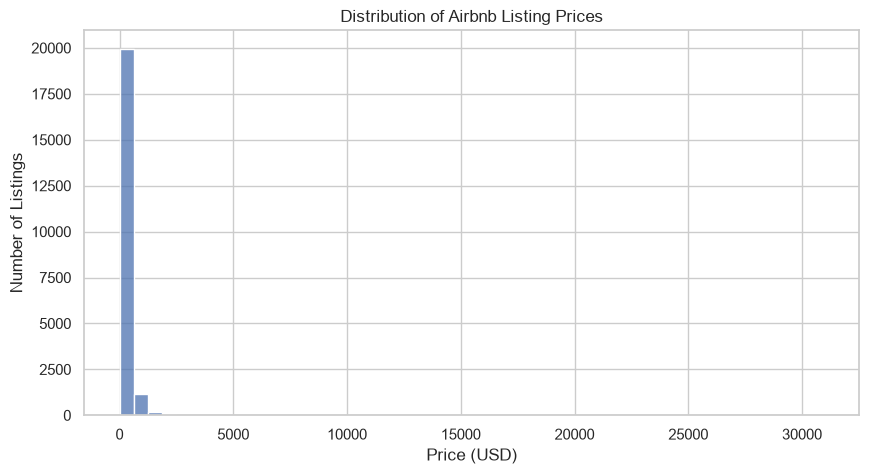

In [5]:
# Section 4.1: Summary Statistics & Distributions
# Task: Explore price distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="price",
    bins=50
)

plt.title("Distribution of Airbnb Listing Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Listings")

plt.show()

## Business Interpretation

The distribution of listing prices is expected to be right-skewed, with most listings concentrated in the lower price range and a small number of luxury listings commanding significantly higher prices.

This suggests that the New York City Airbnb market is dominated by affordable and mid-range properties, while premium listings represent a smaller segment.

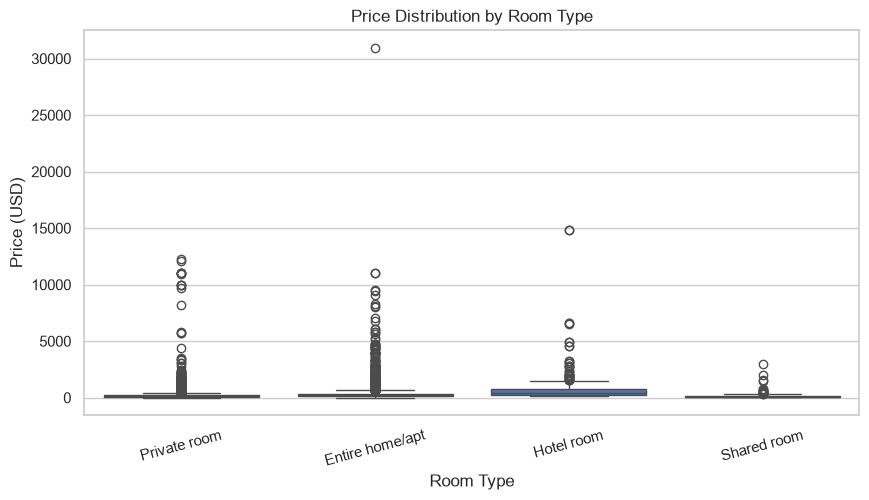

In [6]:
# Section 4.1: Summary Statistics & Distributions
# Task: Compare prices by room type

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="room_type",
    y="price"
)

plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price (USD)")

plt.xticks(rotation=15)

plt.show()

## Business Interpretation

The distribution of Airbnb listing prices is highly right-skewed. Most listings are concentrated in the lower price ranges, while a small number of luxury properties have exceptionally high prices.

The box plot shows that entire homes and hotel rooms tend to be more expensive than private and shared rooms. However, the presence of extreme outliers makes it difficult to compare the typical prices of different room types.

To better understand market patterns, the next analysis will remove or cap extreme values.

In [7]:
# Section 4.1: Summary Statistics & Distributions
# Task: Remove extreme price outliers for visualization

filtered_df = df[df["price"] <= 1000]

print(filtered_df.shape)

(20893, 97)


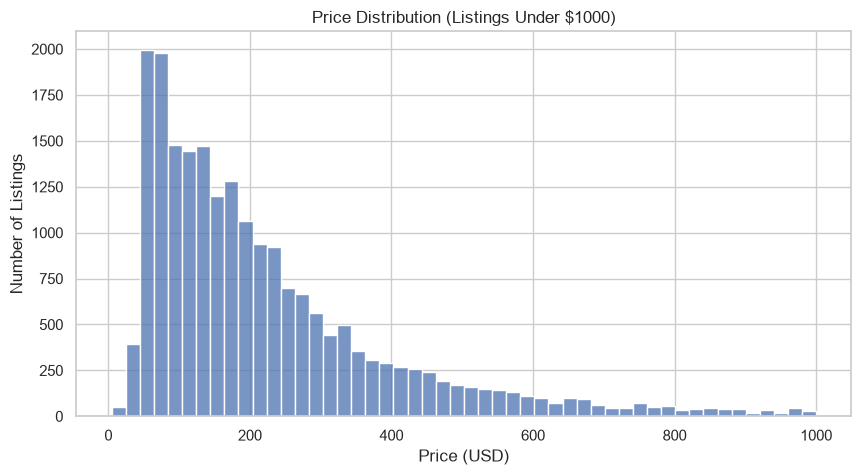

In [ ]:
# Section 4.1: Summary Statistics & Distributions
# Task: Visualize filtered price distribution (rerun histogram)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=filtered_df,
    x="price",
    bins=50
)

plt.title("Price Distribution (Listings Under $1000)")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Listings")

plt.show()

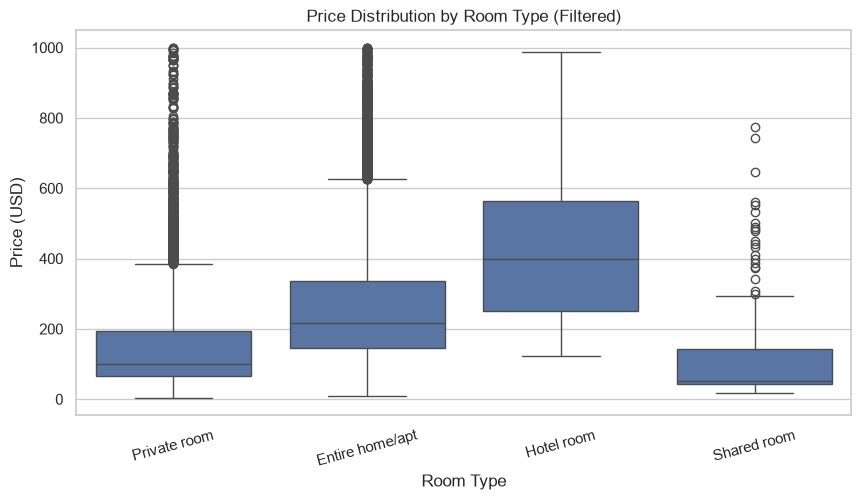

In [9]:
# Section 4.1: Summary Statistics & Distributions
# Task: Compare room types after removing outliers (rerun box plot)

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=filtered_df,
    x="room_type",
    y="price"
)

plt.title("Price Distribution by Room Type (Filtered)")
plt.xlabel("Room Type")
plt.ylabel("Price (USD)")

plt.xticks(rotation=15)

plt.show()

In [10]:
# Section 4.4: Host & Supply-Side Analysis
# Task: Analyze listings per host

host_portfolio = (
    df.groupby("host_id")
    .size()
    .reset_index(name="listing_count")
)

host_portfolio.head()

,host_id,listing_count
0,1678,1
1,2438,1
2,2571,1
3,2787,5
4,2868,1


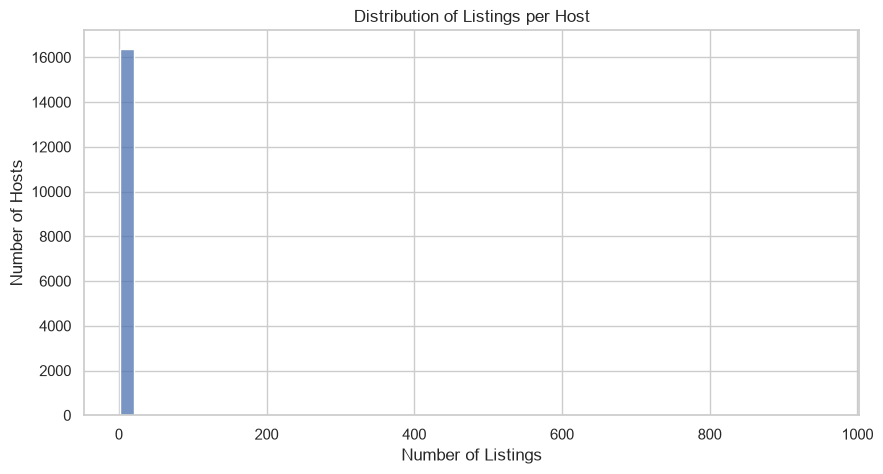

In [11]:
# Section 4.4: Host & Supply-Side Analysis
# Task: Visualize host portfolio sizes

plt.figure(figsize=(10, 5))

sns.histplot(
    data=host_portfolio,
    x="listing_count",
    bins=50
)

plt.title("Distribution of Listings per Host")
plt.xlabel("Number of Listings")
plt.ylabel("Number of Hosts")

plt.show()

## Business Interpretation

Most hosts manage only a small number of listings, while a small group of professional hosts controls a large portfolio of properties.

This indicates that the Airbnb market contains both casual hosts and commercial operators. Understanding this distribution can help platforms and policymakers identify market concentration and potential regulatory concerns.

In [12]:
# Section 4.4: Host & Supply-Side Analysis
# Task: Analyze market concentration

single_hosts = (host_portfolio["listing_count"] == 1).sum()

multi_hosts = (host_portfolio["listing_count"] > 1).sum()

print(f"Hosts with one listing: {single_hosts}")
print(f"Hosts with multiple listings: {multi_hosts}")

Hosts with one listing: 13274
Hosts with multiple listings: 3200


## Business Interpretation

The majority of Airbnb hosts in New York City operate a single listing, with 13,274 hosts managing only one property. In contrast, 3,200 hosts manage multiple listings.

This suggests that while the platform is primarily composed of casual hosts, a relatively small number of professional operators manage a significant share of the market. These commercial hosts may have different pricing strategies, occupancy rates, and operational practices compared to individual hosts.

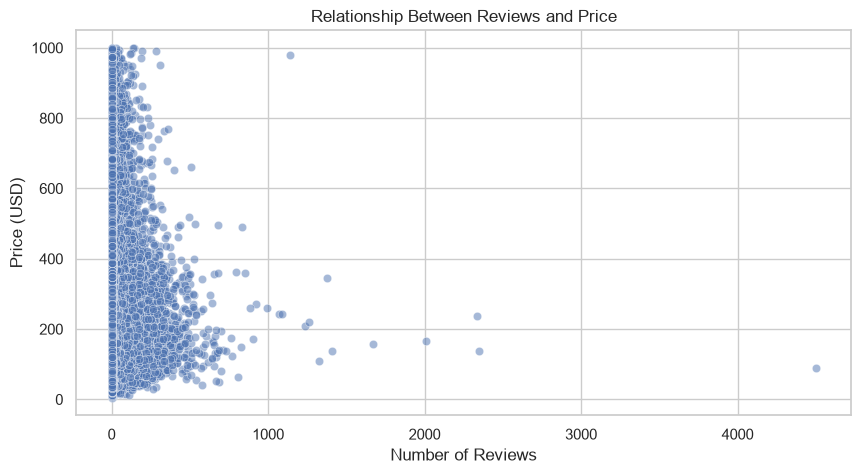

In [13]:
# Section 4.5: Review & Demand-Side Analysis
# Task: Analyze the relationship between reviews and price

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=filtered_df,
    x="number_of_reviews",
    y="price",
    alpha=0.5
)

plt.title("Relationship Between Reviews and Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Price (USD)")

plt.show()

In [17]:
# Section 5.3: Correlation & Driver Analysis
# Task: Compute correlations between numerical features

correlation_columns = [
    "price",
    "number_of_reviews",
    "review_scores_rating",
    "beds",
    "bedrooms",
    "bathrooms_text",
    "reviews_per_month"
]

correlation_matrix = df[
    [col for col in correlation_columns if col in df.columns]
].corr(numeric_only=True)

correlation_matrix

,price,number_of_reviews,review_scores_rating,beds,bedrooms,reviews_per_month
price,1.000000,-0.025051,0.041456,0.267356,0.258095,0.057433
number_of_reviews,-0.025051,1.000000,0.055281,0.022889,-0.009689,0.750334
review_scores_rating,0.041456,0.055281,1.000000,0.015877,0.023518,0.037270
beds,0.267356,0.022889,0.015877,1.000000,0.744849,0.023710
bedrooms,0.258095,-0.009689,0.023518,0.744849,1.000000,-0.007433
reviews_per_month,0.057433,0.750334,0.037270,0.023710,-0.007433,1.000000


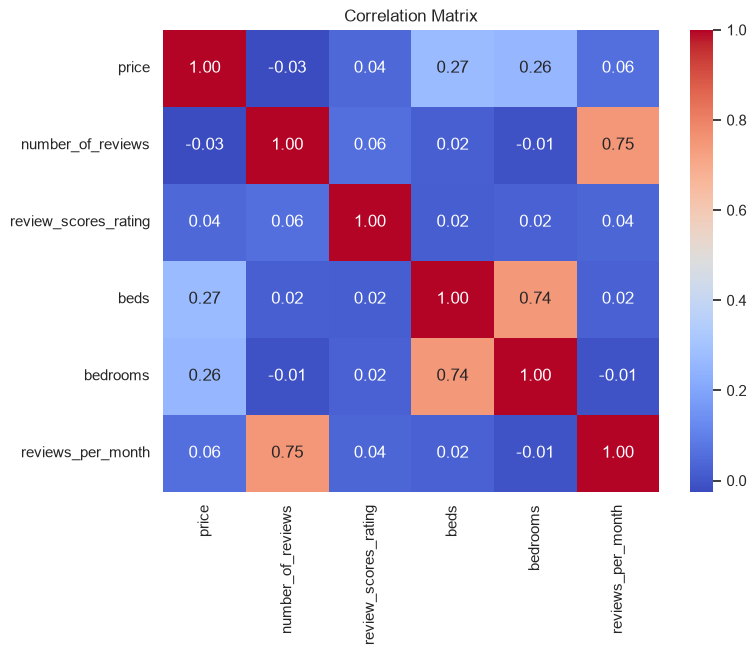

In [16]:
# Section 5.3: Correlation & Driver Analysis
# Task: Visualize correlations

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# Section Summary: Exploratory Data Analysis

## Completed Tasks

- Analyzed the distribution of Airbnb listing prices.
- Compared prices across room types.
- Explored host portfolio sizes and market concentration.
- Investigated the relationship between reviews and prices.
- Computed correlations between key numerical variables.

## Key Findings

- Airbnb prices in New York City are highly right-skewed, with a small number of luxury listings creating extreme outliers.
- Entire homes and hotel rooms tend to have higher prices than private and shared rooms.
- Most hosts manage only one property, while a small number of professional hosts operate multiple listings.
- There is almost no linear relationship between price and the number of reviews.
- Bedrooms and beds show a moderate positive correlation with price.
- Reviews per month and total reviews are strongly correlated (0.75), indicating that frequently reviewed listings tend to accumulate more reviews over time.

## Business Implications

- The market is dominated by affordable and mid-range listings.
- Professional hosts may have different pricing and operational strategies compared to casual hosts.
- Property size appears to influence pricing more than customer ratings.